# Riyadh Bus Stations — Exploratory Data Analysis
---
**Project:** Neighborhood DNA — The 15-Minute City Index  
**Layer:** Transit — Bus (Layer 3b of 4)  
**Objective:** Clean and explore 3,010 bus stops across 88 routes to build the bus transit proximity layer for Riyadh's Livability Score.  

**Pipeline:**
1. Load & Initial Profile
2. Feature Selection
3. Data Processing (types, nulls, duplicates, coordinate parsing)
4. Data Analysis (shelter types, route coverage, development stages, spatial patterns)
5. Fix What Analysis Reveals (coordinate extraction, spatial validation)
6. Export (`Cleaned_Riyadh_Bus.csv`)

## 1 | Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Dark Theme ──
plt.rcParams.update({
    'figure.facecolor': '#0a0e27',
    'axes.facecolor': '#0a0e27',
    'axes.edgecolor': '#2a2f4e',
    'axes.labelcolor': '#c4c7d4',
    'text.color': '#c4c7d4',
    'xtick.color': '#8b8fa3',
    'ytick.color': '#8b8fa3',
    'grid.color': '#1a1f3e',
    'grid.alpha': 0.5,
    'font.family': 'sans-serif',
    'font.size': 11,
    'figure.dpi': 120,
    'figure.figsize': (14, 6)
})

GOLD   = '#f0c05a'
CYAN   = '#4fc3f7'
CORAL  = '#ff6b6b'
MINT   = '#66bb6a'
PURPLE = '#ab47bc'
PALETTE = [GOLD, CYAN, CORAL, MINT, PURPLE, '#ff8a65', '#42a5f5', '#ef5350']

pd.set_option('display.max_columns', None)
print('Setup complete.')

Setup complete.


In [2]:
url = 'https://raw.githubusercontent.com/AbdulrahmanB-25/Machine_Learning_Competition/main/DataSets/bus-stops-in-riyadh-by-bus-route-direction-and-shelter-type.csv'
df_raw = pd.read_csv(url, encoding="utf-8-sig")

print(f"Loaded {len(df_raw):,} bus stop records with {df_raw.shape[1]} columns.")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head()

Loaded 3,010 bus stop records with 13 columns.
Columns: ['Index', 'Bus station code', 'Bus station name', 'Shelter type code', 'Shelter type', 'Bus line code', 'Bus line', 'Direction', 'Sequence of the stops', 'Development stage', 'Comments', 'Geographical coordinates', 'geo_point_2d']


,Index,Bus station code,Bus station name,Shelter type code,Shelter type,Bus line code,Bus line,Direction,Sequence of the stops,Development stage,Comments,Geographical coordinates,geo_point_2d
0,10,41024,Ali Ibn Abi Talib 17 A,A1,BRT station,L31-1,11.0,1.0,13.0,4,NaN,"{""coordinates"": [46.749664, 24.663391], ""type""...","24.663391, 46.749664"
1,40,41100,Salahuddin Al Ayubi 16 B,A3,BRT station,L31-1,11.0,2.0,6.0,4,NaN,"{""coordinates"": [46.741283, 24.660954], ""type""...","24.660954, 46.741283"
2,56,41144,Al Kharj E,-,NaN,NaN,NaN,NaN,55.0,2,Refer to Al Kharj station for the shelter cate...,"{""coordinates"": [46.850805, 24.56117], ""type"":...","24.56117, 46.850805"
3,102,42113,Ali Ibn Abi Talib B,-,NaN,NaN,NaN,NaN,53.0,2,Refer to Ali Ibn Abi Talib A station for the s...,"{""coordinates"": [46.765697, 24.624916], ""type""...","24.624916, 46.765697"
4,104,42115,Ali Ibn Abi Talib D,-,NaN,NaN,NaN,NaN,22.0,3,Refer to Ali Ibn Abi Talib A station for the s...,"{""coordinates"": [46.765927, 24.625256], ""type""...","24.625256, 46.765927"


## 2 | Initial Data Profile
First look at the raw 13-column dataset before any cleaning.

In [3]:
print("=" * 60)
print("DATA TYPES & MISSING VALUES")
print("=" * 60)
info_df = pd.DataFrame({
    'dtype':    df_raw.dtypes,
    'non_null': df_raw.count(),
    'null':     df_raw.isnull().sum(),
    'null_%':   (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(info_df)
print(f"\nTotal rows: {len(df_raw):,}")

DATA TYPES & MISSING VALUES
                            dtype  non_null  null  null_%
Index                       int64      3010     0     0.0
Bus station code            int64      3010     0     0.0
Bus station name           object      3010     0     0.0
Shelter type code          object      3010     0     0.0
Shelter type               object      2998    12     0.4
Bus line code              object      2977    33     1.1
Bus line                  float64      2977    33     1.1
Direction                 float64      2977    33     1.1
Sequence of the stops     float64      2977    33     1.1
Development stage          object      2977    33     1.1
Comments                   object        33  2977    98.9
Geographical coordinates   object      3010     0     0.0
geo_point_2d               object      3010     0     0.0

Total rows: 3,010


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df_raw.describe(include="all")

DESCRIPTIVE STATISTICS


,Index,Bus station code,Bus station name,Shelter type code,Shelter type,Bus line code,Bus line,Direction,Sequence of the stops,Development stage,Comments,Geographical coordinates,geo_point_2d
count,3010.000000,3010.000000,3010,3010,2998,2977,2977.000000,2977.000000,2977.000000,2977,33,3010,3010
unique,NaN,NaN,3010,12,8,88,NaN,NaN,NaN,7,8,3009,3009
top,NaN,NaN,Al Batha 204,6,Feeder pole with reduced site adaptation,L37-1,NaN,NaN,NaN,Stage beyond 5.2,"Temporary stop, not assigned to a route number...","{""coordinates"": [46.7380372940383, 24.68031964...","24.6803196441901, 46.7380372940383"
freq,NaN,NaN,1,1844,1844,84,NaN,NaN,NaN,849,9,2,2
mean,1505.621595,60802.500332,NaN,NaN,NaN,NaN,639.342627,1.209607,18.705744,NaN,NaN,NaN,NaN
std,869.275416,9023.291282,NaN,NaN,NaN,NaN,382.771447,0.407097,12.958373,NaN,NaN,NaN,NaN
min,1.000000,41001.000000,NaN,NaN,NaN,NaN,7.000000,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,753.250000,53531.250000,NaN,NaN,NaN,NaN,231.000000,1.000000,9.000000,NaN,NaN,NaN,NaN
50%,1505.500000,62403.500000,NaN,NaN,NaN,NaN,922.000000,1.000000,17.000000,NaN,NaN,NaN,NaN
75%,2257.750000,65218.750000,NaN,NaN,NaN,NaN,954.000000,1.000000,26.000000,NaN,NaN,NaN,NaN


## 3 | Feature Selection

From 13 raw columns, we keep **4 features** needed for the Transit layer:

### Kept Features:
| Feature | Role |
|---|---|
| `Bus station name` | Stop identity — needed for labeling |
| `Shelter type` | Infrastructure quality (BRT, air-conditioned, open, pole) — indicates transit investment |
| `Development stage` | Build-out phase — reveals planned vs operational stops |
| `geo_point_2d` | Coordinates — will be parsed into `lat` / `lng` for spatial joining |

### Dropped Features & Rationale:
| Column(s) | Why Dropped |
|---|---|
| `Index` | Row index from original source — no analytical value |
| `Bus station code` | Internal numeric ID — redundant with station name |
| `Shelter type code` | Coded version of shelter type (A1, A3…) — redundant with `Shelter type` text |
| `Bus line code` | Internal line code — redundant with `Bus line` |
| `Bus line` | Route number — a single stop can serve multiple routes; 1.1% null; not needed for proximity |
| `Direction` | Inbound vs outbound (1/2) — same physical stop regardless of direction |
| `Sequence of the stops` | Stop ordering within a route — not needed for spatial proximity |
| `Comments` | 99% null — virtually no data |
| `Geographical coordinates` | Raw JSON format — `geo_point_2d` is the cleaner parsed version |

In [5]:
keep_cols = ['Bus station name', 'Shelter type', 'Development stage', 'geo_point_2d']
df = df_raw[keep_cols].copy()

print(f"Selected {len(df.columns)} features from {df_raw.shape[1]} available.")
print(f"Dropped {df_raw.shape[1] - len(df.columns)} columns.")
print(f"Shape: {df.shape}")
df.head()

Selected 4 features from 13 available.
Dropped 9 columns.
Shape: (3010, 4)


,Bus station name,Shelter type,Development stage,geo_point_2d
0,Ali Ibn Abi Talib 17 A,BRT station,4,"24.663391, 46.749664"
1,Salahuddin Al Ayubi 16 B,BRT station,4,"24.660954, 46.741283"
2,Al Kharj E,NaN,2,"24.56117, 46.850805"
3,Ali Ibn Abi Talib B,NaN,2,"24.624916, 46.765697"
4,Ali Ibn Abi Talib D,NaN,3,"24.625256, 46.765927"


## 4 | Data Processing
Parse coordinates, handle nulls, validate bounds, and remove duplicates.

In [6]:
initial_count = len(df)
cleaning_log = []

# Step 1: Parse geo_point_2d into lat/lng
df['lat'] = df['geo_point_2d'].str.split(', ').str[0].astype(float)
df['lng'] = df['geo_point_2d'].str.split(', ').str[1].astype(float)
df = df.drop(columns=['geo_point_2d'])
print(f"Step 1 — Parsed coordinates: lat [{df['lat'].min():.4f} – {df['lat'].max():.4f}], lng [{df['lng'].min():.4f} – {df['lng'].max():.4f}]")

# Step 2: Drop rows with null shelter type or development stage
before = len(df)
df = df.dropna(subset=['Shelter type', 'Development stage'])
removed = before - len(df)
cleaning_log.append(('Null shelter type or dev stage', removed))
print(f"Step 2 — Null values removed: {removed:,}")

# Step 3: Validate coordinates within Riyadh bounds
before = len(df)
lat_ok = (df['lat'] >= 24.3) & (df['lat'] <= 25.1)
lng_ok = (df['lng'] >= 46.2) & (df['lng'] <= 47.1)
df = df[lat_ok & lng_ok]
removed = before - len(df)
cleaning_log.append(('Outside Riyadh bounds', removed))
print(f"Step 3 — Outside Riyadh bounds removed: {removed:,}")

# Step 4: Remove exact duplicates
before = len(df)
df = df.drop_duplicates()
removed = before - len(df)
cleaning_log.append(('Exact duplicates', removed))
print(f"Step 4 — Exact duplicates removed: {removed:,}")

df = df.reset_index(drop=True)

total_removed = initial_count - len(df)
print(f'\n{"=" * 60}')
print("CLEANING SUMMARY")
print(f'{"=" * 60}')
print(f"Started with:  {initial_count:,}")
print(f"Removed total: {total_removed:,} ({total_removed/initial_count*100:.2f}%)")
print(f"Final count:   {len(df):,}")

Step 1 — Parsed coordinates: lat [24.4923 – 24.8549], lng [46.5230 – 46.9264]
Step 2 — Null values removed: 45
Step 3 — Outside Riyadh bounds removed: 0
Step 4 — Exact duplicates removed: 0

CLEANING SUMMARY
Started with:  3,010
Removed total: 45 (1.50%)
Final count:   2,965


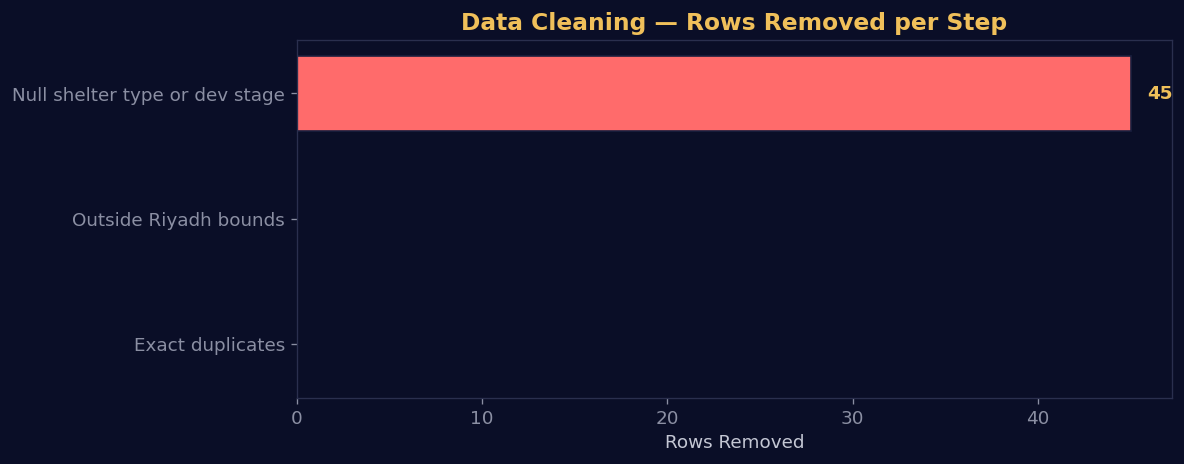

In [7]:
# ── Cleaning Summary Chart ──
fig, ax = plt.subplots(figsize=(10, 4))
steps  = [s[0] for s in cleaning_log]
counts = [s[1] for s in cleaning_log]
colors = [CORAL if c > 0 else "#2a2f4e" for c in counts]

bars = ax.barh(steps, counts, color=colors, edgecolor="#1a1f3e", height=0.6)
for bar, count in zip(bars, counts):
    if count > 0:
        ax.text(bar.get_width() + max(max(counts), 1) * 0.02,
                bar.get_y() + bar.get_height() / 2,
                f'{count:,}', va='center', fontsize=11, color=GOLD, fontweight='bold')

ax.set_xlabel('Rows Removed')
ax.set_title('Data Cleaning — Rows Removed per Step', fontsize=14, fontweight='bold', color=GOLD)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5 | Data Analysis
Explore shelter types, development stages, and spatial coverage.

### 5.1 | Shelter Type Distribution

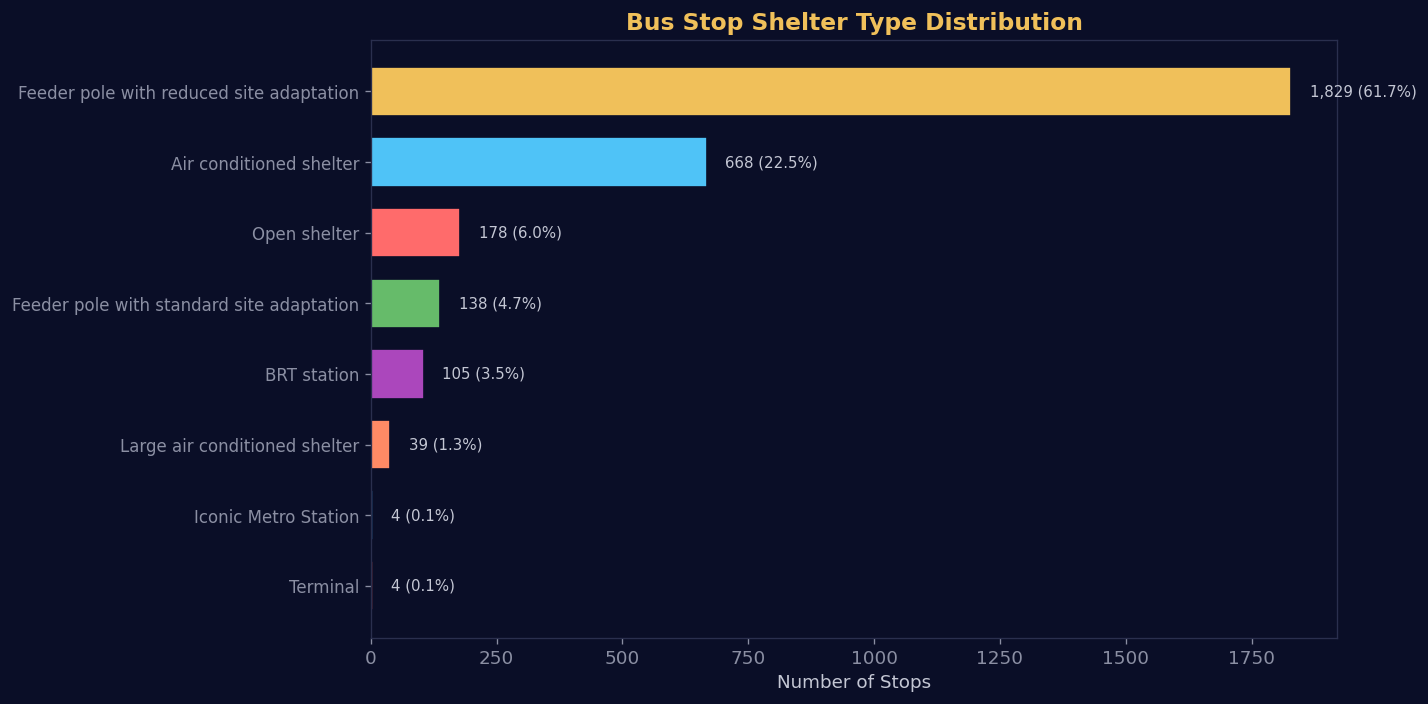

In [8]:
shelter_counts = df['Shelter type'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
colors = PALETTE[:len(shelter_counts)]
bars = ax.barh(range(len(shelter_counts)), shelter_counts.values, color=colors,
               edgecolor="#0a0e27", height=0.7)
ax.set_yticks(range(len(shelter_counts)))
ax.set_yticklabels(shelter_counts.index, fontsize=10)
ax.invert_yaxis()

for bar, val in zip(bars, shelter_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + max(shelter_counts.values) * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=9, color='#c4c7d4')

ax.set_xlabel('Number of Stops')
ax.set_title('Bus Stop Shelter Type Distribution', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

### 5.2 | Development Stage Distribution

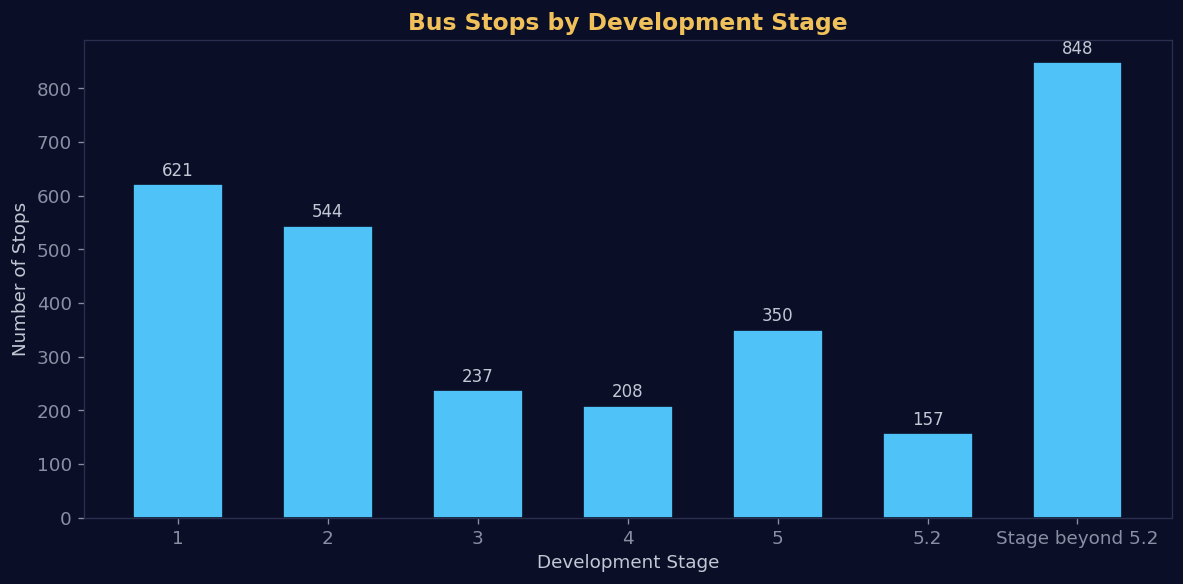

In [9]:
stage_counts = df['Development stage'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(stage_counts.index.astype(str), stage_counts.values, color=CYAN,
       edgecolor="#0a0e27", width=0.6)

for x, y in zip(range(len(stage_counts)), stage_counts.values):
    ax.text(x, y + max(stage_counts.values) * 0.02,
            f'{y:,}', ha='center', fontsize=10, color='#c4c7d4')

ax.set_xlabel('Development Stage')
ax.set_ylabel('Number of Stops')
ax.set_title('Bus Stops by Development Stage', fontsize=14, fontweight='bold', color=GOLD)
plt.tight_layout()
plt.show()

### 5.3 | Shelter Type vs Development Stage

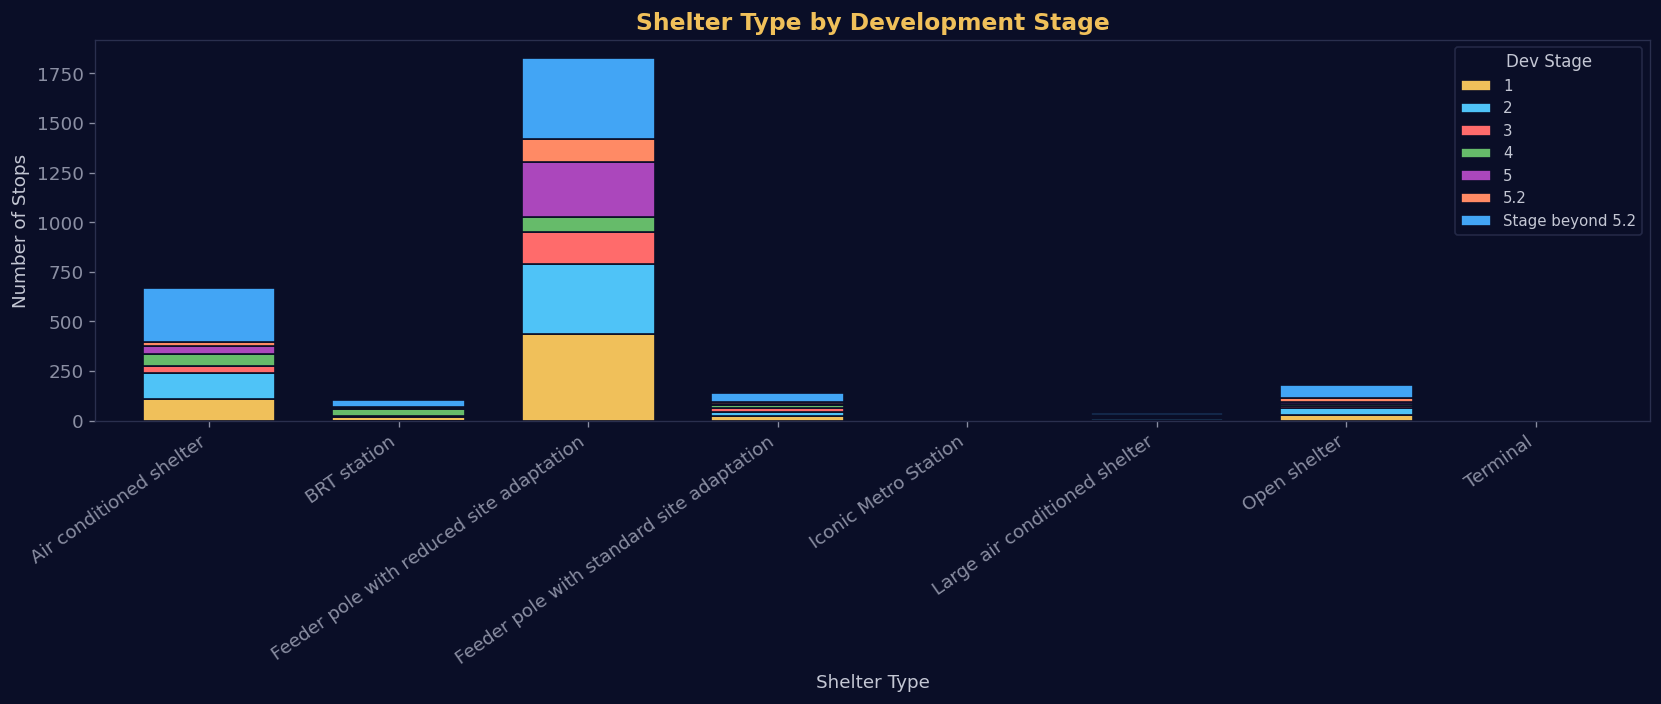

In [10]:
ct = pd.crosstab(df['Shelter type'], df['Development stage'])

fig, ax = plt.subplots(figsize=(14, 6))
ct.plot(kind="bar", stacked=True, ax=ax, color=PALETTE[:len(ct.columns)],
        edgecolor="#0a0e27", width=0.7)
ax.set_xlabel('Shelter Type')
ax.set_ylabel('Number of Stops')
ax.set_title('Shelter Type by Development Stage', fontsize=14, fontweight='bold', color=GOLD)
ax.legend(title="Dev Stage", facecolor="#0a0e27", edgecolor="#2a2f4e",
          title_fontsize=10, fontsize=9)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

### 5.4 | Spatial Distribution
Mapping all bus stops across Riyadh, colored by shelter type.

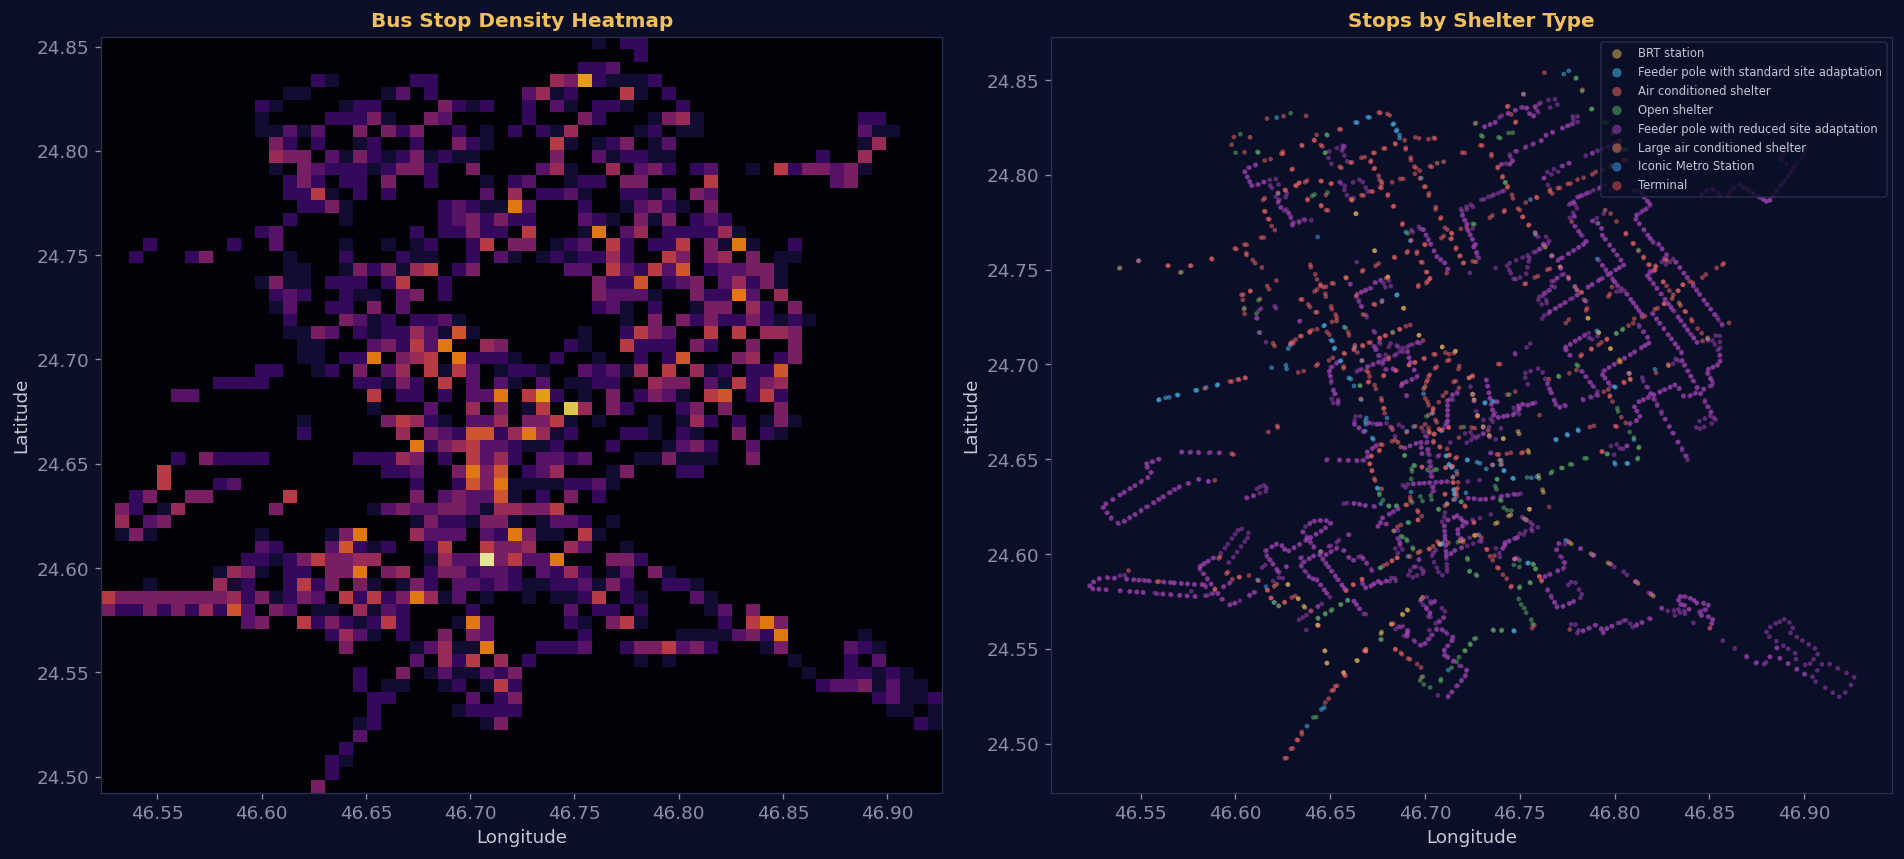

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: density heatmap
ax1 = axes[0]
ax1.hist2d(df['lng'], df['lat'], bins=60, cmap='inferno', alpha=0.9)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Bus Stop Density Heatmap', fontsize=12, fontweight='bold', color=GOLD)
ax1.set_aspect('equal')

# Right: colored by shelter type
ax2 = axes[1]
shelter_types = df['Shelter type'].unique()
for i, stype in enumerate(shelter_types):
    subset = df[df['Shelter type'] == stype]
    ax2.scatter(subset["lng"], subset["lat"], c=PALETTE[i % len(PALETTE)],
               s=8, alpha=0.5, label=stype, edgecolors="none")
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Stops by Shelter Type', fontsize=12, fontweight='bold', color=GOLD)
ax2.set_aspect('equal')
ax2.legend(facecolor="#0a0e27", edgecolor="#2a2f4e", fontsize=7,
           loc="upper right", markerscale=2)

plt.tight_layout()
plt.show()

## 6 | Fix What Analysis Reveals
The data is relatively clean after processing — no major issues uncovered by the analysis. All coordinates fall within Riyadh, shelter types are well-distributed, and there are no unrealistic values to fix.

### 6.1 | Final Clean Dataset Profile

In [12]:
print("=" * 60)
print("FINAL CLEAN DATASET PROFILE")
print("=" * 60)
print(f"Rows:    {len(df):,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumn Details:")
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<10} | nulls: {df[col].isnull().sum()} | unique: {df[col].nunique():,}")
print(f"\nDescriptive Stats:")
df.describe(include="all")

FINAL CLEAN DATASET PROFILE
Rows:    2,965
Columns: 5

Column Details:
  Bus station name          object     | nulls: 0 | unique: 2,965
  Shelter type              object     | nulls: 0 | unique: 8
  Development stage         object     | nulls: 0 | unique: 7
  lat                       float64    | nulls: 0 | unique: 2,948
  lng                       float64    | nulls: 0 | unique: 2,952

Descriptive Stats:


,Bus station name,Shelter type,Development stage,lat,lng
count,2965,2965,2965,2965.000000,2965.000000
unique,2965,8,7,NaN,NaN
top,Al Batha 204,Feeder pole with reduced site adaptation,Stage beyond 5.2,NaN,NaN
freq,1,1829,848,NaN,NaN
mean,NaN,NaN,NaN,24.679222,46.720177
std,NaN,NaN,NaN,0.082659,0.082123
min,NaN,NaN,NaN,24.492291,46.523016
25%,NaN,NaN,NaN,24.604392,46.664171
50%,NaN,NaN,NaN,24.680508,46.714205
75%,NaN,NaN,NaN,24.747288,46.781962


## 7 | Export Clean Dataset
Final bus stop dataset ready for transit proximity calculations.

In [13]:
output_file = 'Cleaned_Riyadh_Bus.csv'
df.to_csv(output_file, index=False, encoding="utf-8-sig")

print(f"Exported: '{output_file}'")
print(f"   Stops:   {len(df):,}")
print(f"   Columns: {list(df.columns)}")
print(f"   Size:    {os.path.getsize(output_file) / 1024:.1f} KB")

try:
    from google.colab import files
    files.download(output_file)
except ImportError:
    print("   (Not in Colab — file saved locally)")

Exported: 'Cleaned_Riyadh_Bus.csv'
   Stops:   2,965
   Columns: ['Bus station name', 'Shelter type', 'Development stage', 'lat', 'lng']
   Size:    225.5 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8 | Key Findings & Next Steps

### What We Learned:
1. **Network Scale**: 2,965+ bus stops across 88 routes — significantly denser coverage than the metro network.
2. **Infrastructure Quality**: 62% of stops are basic feeder poles, while only 23% have air-conditioned shelters and 4% are BRT stations — reveals a tiered transit infrastructure.
3. **Development Phases**: Stops are spread across 7 development stages, with "Stage beyond 5.2" being the largest — suggests ongoing network expansion.
4. **Spatial Coverage**: Bus stops cover a wider area than metro stations, reaching into southern and eastern Riyadh where metro has no presence.

### Next Steps:
- Combine with metro station data for complete transit coverage scoring.
- Calculate transit proximity per neighborhood (distance to nearest stop, weighted by infrastructure quality).
- Feed into the composite Livability Score model.